In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec
import matplotlib.colors as colors


import os
import scanpy as sc

import seaborn as sns
import snapatac2 as snap

snap.__version__



plt.rcParams['figure.dpi'] = 167
plt.rcParams['font.size'] = 14
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [font for font in 'Liberation Sans, DejaVu Sans, Arial, Helvetica, Lucida Grande, Verdana, Geneva, Lucid, Avant Garde, sans-serif'.split(', ')] 
plt.rcParams['mathtext.fontset'] = 'stixsans'

plt.rcParams['axes.linewidth'] = 1
plt.rcParams['grid.linewidth'] = 1
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 6




/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Data

In [3]:
blacklist_file = '/home/syyang/GitRepo/atac/ref/hg38/hg38-blacklist.bed'

In [5]:
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')
Union_cell_info_file = os.path.join(Union_cell_subdir, 'Union_cell_3set_with_stringent_calling.tsv')
union_cell_info = pd.read_csv(Union_cell_info_file, sep='\t', index_col=0)
union_cell_info['index'] = union_cell_info.index.map(lambda x: x + '-1')

union_cell_info.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris,_3set_identified_by_atac,P_closed_state,stringent_cell_calling,index
atac_bc,,,,,,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,3,NO,common,0.965116,True,AAACAAGCAAGTTAGT-1
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,0,NO,common,0.990949,True,AAACAAGCATTTCTTC-1


In [ ]:
# nucleosome_info_file = os.path.join(Union_cell_subdir, 'nucleosome_signal_by_cell.csv')
# nucleosome_info = pd.read_csv(nucleosome_info_file, index_col=0)
# nucleosome_info['index'] = nucleosome_info.index.map(lambda x: x + '-1')
# nucleosome_info.head(2)

,nucleosome_signal,index
atac_bc,,
AAACAAGCAAGTTAGT,-1.552972,AAACAAGCAAGTTAGT-1
AAACAAGCATTTCTTC,-1.926050,AAACAAGCATTTCTTC-1


In [6]:
frip_score_file = os.path.join(Union_cell_subdir, 'frip_cells_info.tsv')
frip_score_info = pd.read_csv(frip_score_file, sep='\t', index_col=0)
frip_score_info['index'] = frip_score_info.index.map(lambda x: x + '-1')
frip_score_info.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,...,FRIP_entropy_peaks,Nfrag_in_tsse_peaks,FRIP_tsse_peaks,Nfrag_in_cr_peaks,FRIP_cr_peaks,Nfrag_in_common_peaks,FRIP_common_peaks,Nfrag_in_blacklist,blacklist_ratio,index
atac_bc,,,,,,,,,,,,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,3,...,0.795605,1933,0.801410,1785,0.740050,1932,0.800995,19.0,0.007877,AAACAAGCAAGTTAGT-1
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,0,...,0.204540,1877,0.207863,1635,0.181063,1878,0.207973,90.0,0.009967,AAACAAGCATTTCTTC-1


In [7]:
amulet_doublet_atac_file = os.path.join(Union_cell_subdir, 'AMULET_output/MultipletBarcodes_01.txt')
doublet_atac_barcodes = pd.read_csv(amulet_doublet_atac_file, header=None)
doublet_atac_barcodes.columns = ['barcodes']
doublet_atac_barcodes['atac_bc'] = doublet_atac_barcodes['barcodes'].str.split('-').str[0]
doublet_atac_barcodes.head(2)



,barcodes,atac_bc
0,AAAGCCTAGGATTATG-1,AAAGCCTAGGATTATG
1,AAAGGCGCACTAATCC-1,AAAGGCGCACTAATCC


In [8]:
fragment_file = os.path.join(entropy_dir, '_cell_calling_comparison', 'union_bc_fragments.tsv.gz')

In [ ]:
data = snap.pp.import_fragments(
    fragment_file,
    chrom_sizes=snap.genome.hg38,
    sorted_by_barcode=False,
)
data

AnnData object with n_obs × n_vars = 2384 × 0
    obs: 'n_fragment', 'frac_dup', 'frac_mito'
    uns: 'reference_sequences'
    obsm: 'fragment_paired'

In [11]:
col_list = ['rna_pass_CR', 'atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS', '_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST', '_3set_identified_by_atac', 
            'DNA_debris']
for col in col_list:
    data.obs[col] = data.obs.index.map(union_cell_info.set_index('index')[col])

data.obs['amulet_doublet_atac'] = data.obs.index.isin(doublet_atac_barcodes['barcodes'])

data.obs['leiden_RNA_scVI'] = data.obs.index.map(union_cell_info.set_index('index')['leiden_RNA_scVI'])

col_list2 = ['total_fragments', 'FRIP_raw_peaks', 'FRIP_entropy_peaks', 'FRIP_tss_peaks', 'FRIP_frip_peaks']
for col in col_list2:
    data.obs[col] = data.obs.index.map(frip_score_info.set_index('index')[col])


data.obs['nucleosome_signal'] = data.obs.index.map(nucleosome_info.set_index('index')['nucleosome_signal'])

In [12]:
data.obs.groupby([ '_3set_identified_by_atac',  'amulet_doublet_atac']).size().unstack(fill_value=0)

amulet_doublet_atac,False,True
_3set_identified_by_atac,,
CR unique,41,20
"CR+TSS, not SADE",33,0
SADE unique,118,0
"SADE+CR, not TSS",62,11
"SADE+TSS, not CR",118,0
TSS unique,189,0
common,1727,65


In [13]:
data

AnnData object with n_obs × n_vars = 2384 × 0
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'rna_pass_CR', 'atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS', '_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST', '_3set_identified_by_atac', 'DNA_debris', 'amulet_doublet_atac', 'leiden_RNA_scVI', 'total_fragments', 'FRIP_raw_peaks', 'FRIP_entropy_peaks', 'FRIP_tss_peaks', 'FRIP_frip_peaks', 'nucleosome_signal'
    uns: 'reference_sequences'
    obsm: 'fragment_paired'

In [14]:
snap.metrics.tsse(data, snap.genome.hg38)


Text(0, 0.5, 'Log10(Total Fragments)')

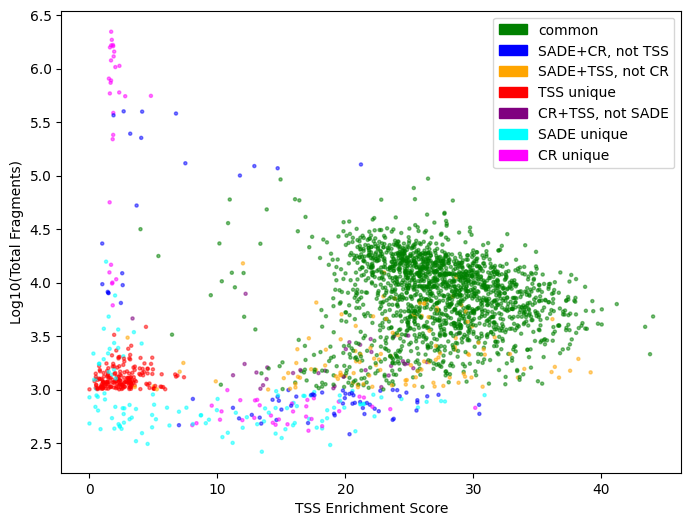

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

labels = ['common', 'SADE+CR, not TSS', 'SADE+TSS, not CR', 'TSS unique',
       'CR+TSS, not SADE', 'SADE unique', 'CR unique']
label_color_dict = {
    'common': 'green',
    'SADE+CR, not TSS': 'blue',
    'SADE+TSS, not CR': 'orange',
    'TSS unique': 'red',
    'CR+TSS, not SADE': 'purple',
    'SADE unique': 'cyan',
    'CR unique': 'magenta'
}

v1 = ax.scatter(data.obs['tsse'], np.log1p(data.obs['n_fragment']),
                c = data.obs['_3set_identified_by_atac'].map(label_color_dict), s=5, alpha=0.5)
ax.legend(handles=[mpatches.Patch(color=color, label=label) for label, color in label_color_dict.items()])
ax.set_xlabel('TSSs Score')
ax.set_ylabel('Read depth ($log_1p$)')

# Clustering on ATAC modality among Union cells 

## Use all cells in the union set -- (not filtering out DNA-debris or amulet estimated doublets)

In [16]:
snap.pp.add_tile_matrix(data)

snap.pp.select_features(data, blacklist=blacklist_file)

snap.tl.spectral(data) # low rank approximation

snap.pp.knn(data) # build similarity graph

snap.tl.leiden(data, resolution=1.5) # cluster cells

snap.tl.umap(data) # umap visualization embedding

2026-04-19 15:21:40 - INFO - Selected 496371 features.
/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


In [17]:
data

AnnData object with n_obs × n_vars = 2384 × 6062095
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'rna_pass_CR', 'atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS', '_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST', '_3set_identified_by_atac', 'DNA_debris', 'amulet_doublet_atac', 'leiden_RNA_scVI', 'total_fragments', 'FRIP_raw_peaks', 'FRIP_entropy_peaks', 'FRIP_tss_peaks', 'FRIP_frip_peaks', 'nucleosome_signal', 'tsse', 'leiden'
    var: 'count', 'selected'
    uns: 'reference_sequences', 'library_tsse', 'frac_overlap_TSS', 'TSS_profile', 'spectral_eigenvalue'
    obsm: 'fragment_paired', 'X_spectral', 'X_umap'
    obsp: 'distances'

... storing '_2set_identified_by_atac_SC' as categorical
... storing '_2set_identified_by_atac_ST' as categorical
... storing '_3set_identified_by_atac' as categorical
... storing 'DNA_debris' as categorical
... storing 'leiden_RNA_scVI' as categorical
... storing 'leiden' as categorical


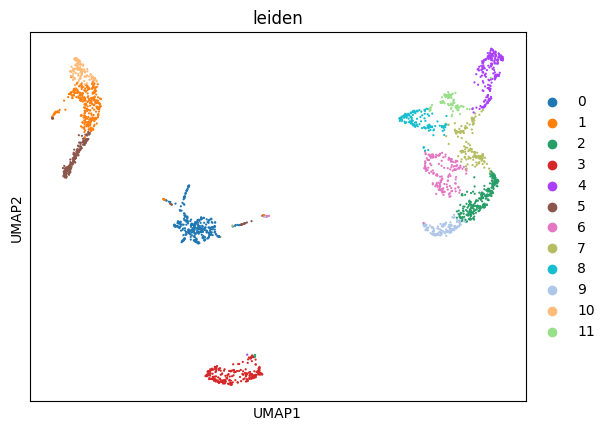

In [18]:
sc.pl.umap(data, color='leiden',s = 10)

In [19]:

data.obs.groupby(['_3set_identified_by_atac', 'leiden'] ).size().unstack(fill_value=0)

/tmp/ipykernel_999780/4253258582.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.obs.groupby(['_3set_identified_by_atac', 'leiden'] ).size().unstack(fill_value=0)


leiden,0,1,2,3,4,5,6,7,8,9,10,11
_3set_identified_by_atac,,,,,,,,,,,,
CR unique,29,0,7,5,1,13,0,6,0,0,0,0
"CR+TSS, not SADE",4,0,4,7,0,7,0,11,0,0,0,0
SADE unique,63,0,11,4,2,16,0,22,0,0,0,0
"SADE+CR, not TSS",21,0,11,6,5,11,0,18,0,1,0,0
"SADE+TSS, not CR",7,2,17,16,15,36,4,16,3,1,1,0
TSS unique,189,0,0,0,0,0,0,0,0,0,0,0
common,12,307,210,193,191,125,176,76,143,141,133,85


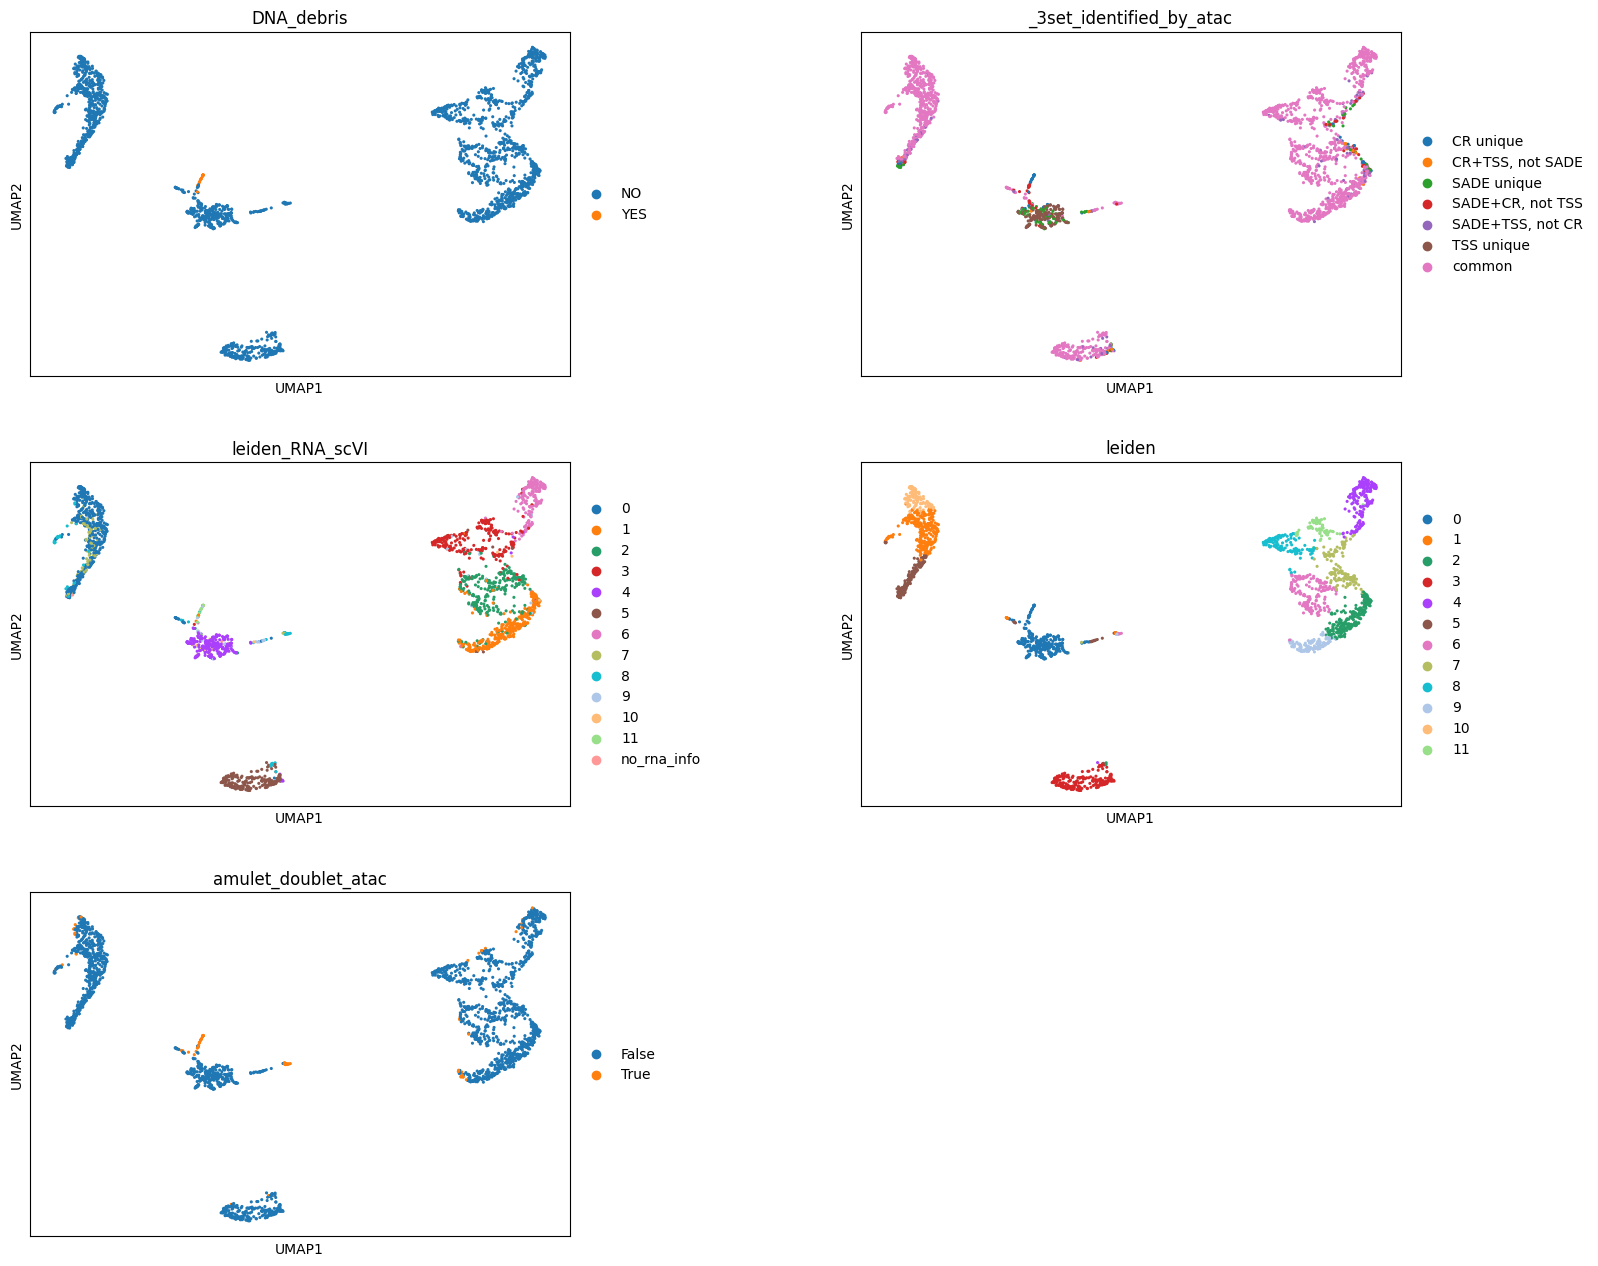

In [20]:
sc.pl.umap(data, color=['DNA_debris', '_3set_identified_by_atac', 'leiden_RNA_scVI', 'leiden', 'amulet_doublet_atac'], s=20, ncols=2, wspace=0.4)

## Use cells in the union set after filtering out DNA-debris or amulet estimated doublets 

In [31]:
data_filter = data[ (data.obs['amulet_doublet_atac'] == False) & (data.obs['DNA_debris'] == 'NO') ].copy()


In [32]:
data_filter

AnnData object with n_obs × n_vars = 2286 × 6062095
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'rna_pass_CR', 'atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS', '_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST', '_3set_identified_by_atac', 'DNA_debris', 'amulet_doublet_atac', 'leiden_RNA_scVI', 'total_fragments', 'FRIP_raw_peaks', 'FRIP_entropy_peaks', 'FRIP_tss_peaks', 'FRIP_frip_peaks', 'nucleosome_signal', 'tsse', 'leiden', 'leiden_scanpy'
    var: 'count', 'selected'
    uns: 'reference_sequences', 'library_tsse', 'frac_overlap_TSS', 'TSS_profile', 'spectral_eigenvalue', 'leiden_colors', 'DNA_debris_colors', '_3set_identified_by_atac_colors', 'leiden_RNA_scVI_colors', 'amulet_doublet_atac_colors', 'leiden_scanpy', 'leiden_scanpy_colors'
    obsm: 'fragment_paired', 'X_spectral', 'X_umap'
    obsp: 'distances'

In [ ]:
snap.pp.select_features(data_filter, blacklist=blacklist_file)

a = snap.tl.spectral(data_filter, inplace=False)
 
data_filter.obsm['filtered_X_spectral'] = a[1]
data_filter.uns['filtered_spectral_eigenvalue'] = a[0]

data_filter.obsp['filtered_distance'] = snap.pp.knn(data_filter, use_rep='filtered_X_spectral', inplace=False)

data_filter.uns['filtered_distance'] ='filtered_distance'  # point to the name in obsp 

data_filter.obsm['filtered_X_umap'] = snap.tl.umap(data_filter,  use_rep='filtered_X_spectral',inplace=False)

data_filter.obs['filtered_leiden'] = snap.tl.leiden(data_filter.obsp['filtered_distance'], 
             resolution=1.5) # cluster cells

2026-04-19 15:50:30 - INFO - Selected 497281 features.
/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


... storing 'filtered_leiden' as categorical


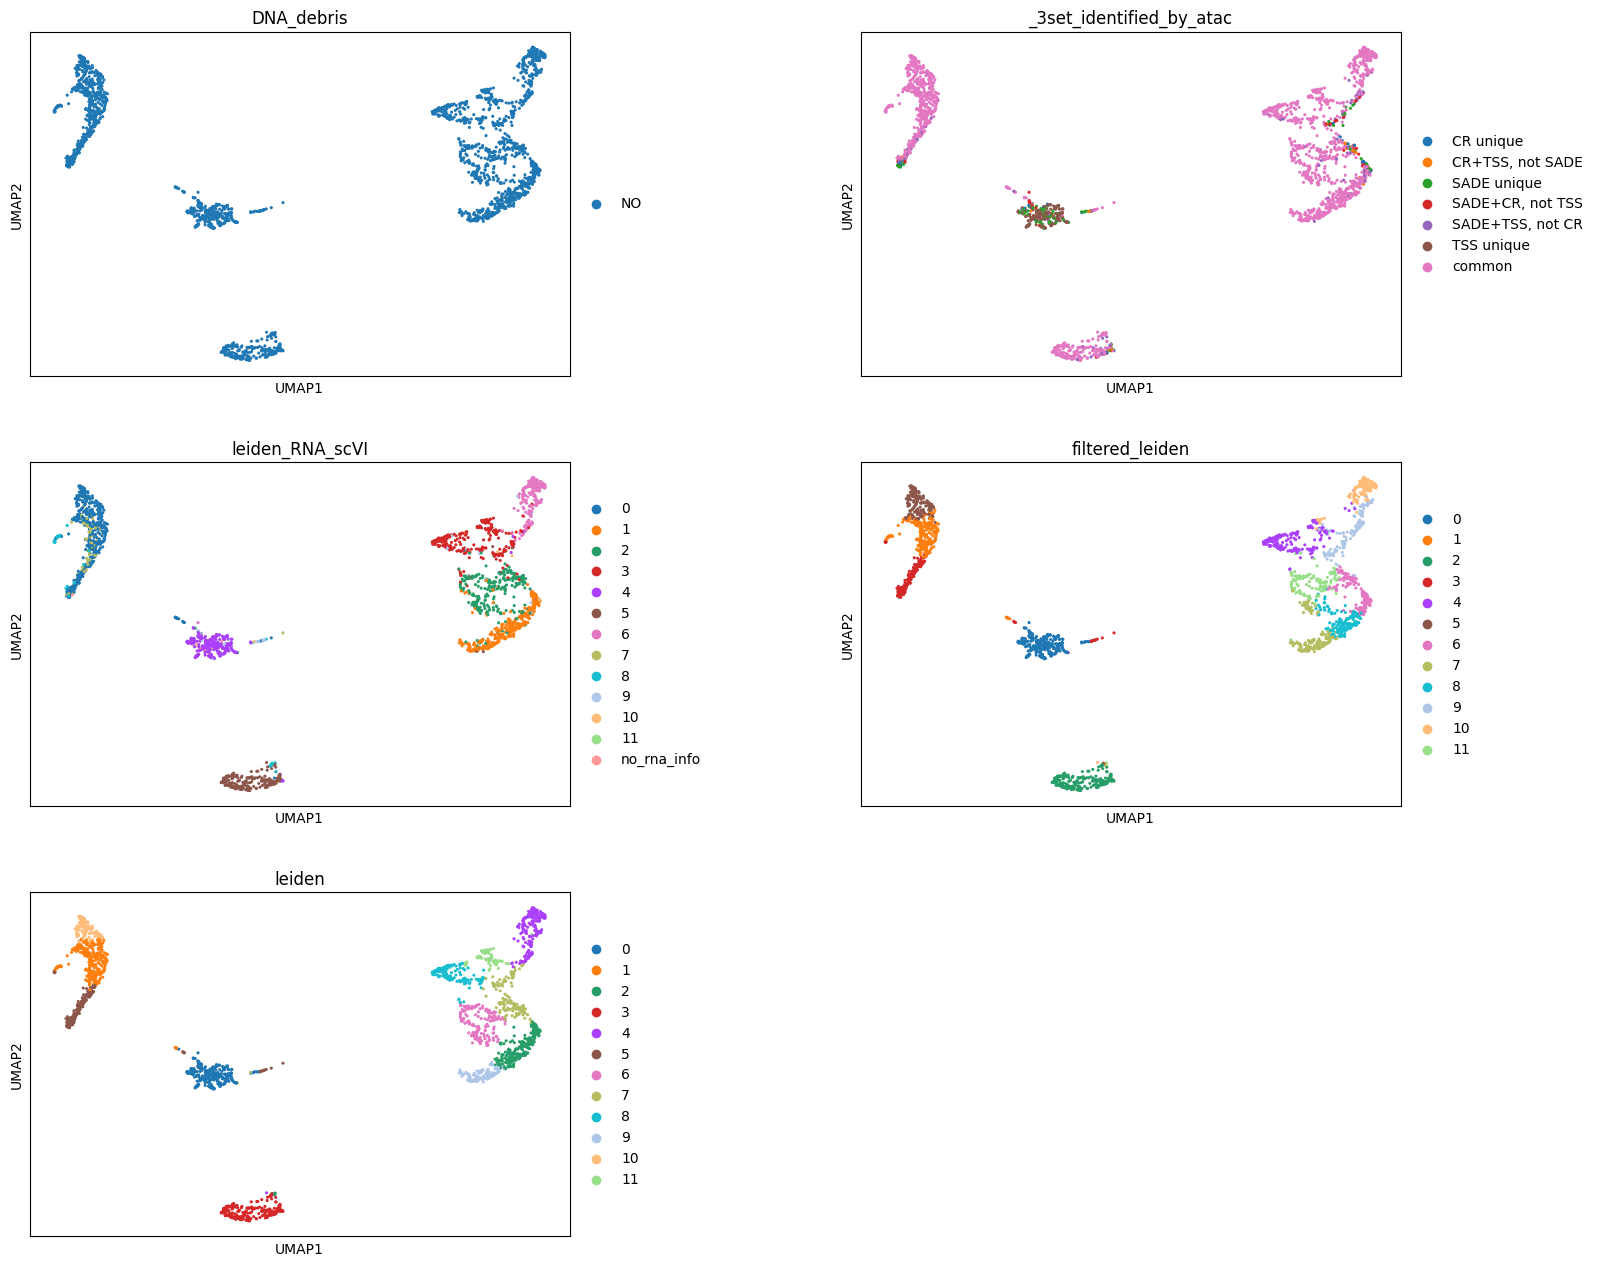

In [62]:
sc.pl.umap(data_filter, color=['DNA_debris', '_3set_identified_by_atac', 'leiden_RNA_scVI', 'filtered_leiden', 'leiden'], s=20, ncols=2, wspace=0.4)

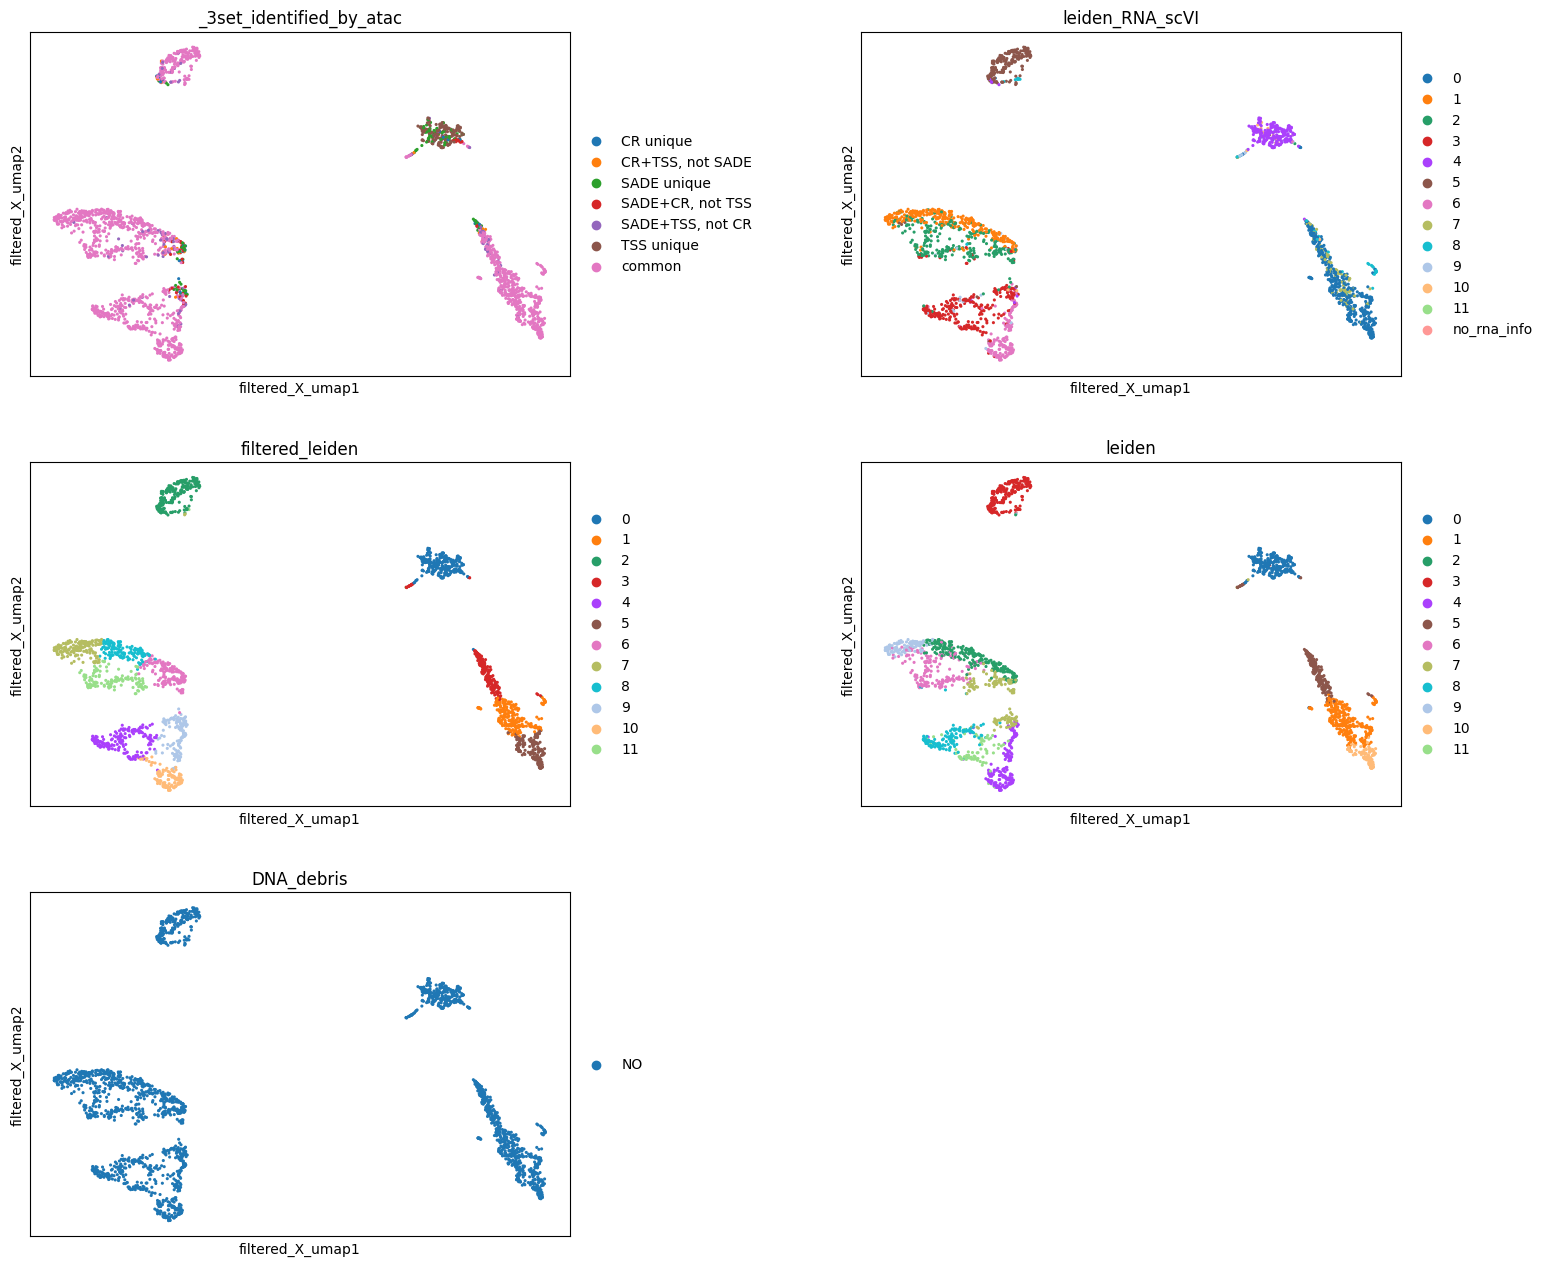

In [73]:
sc.pl.embedding(data_filter,basis='filtered_X_umap', color=[ '_3set_identified_by_atac', 'leiden_RNA_scVI', 'filtered_leiden', 'leiden', 'DNA_debris'], s=20, ncols=2, wspace=0.4)

In [72]:
data_filter.obs.groupby(['leiden', 'filtered_leiden'] ).size().unstack(fill_value=0)

/tmp/ipykernel_999780/1483797836.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_filter.obs.groupby(['leiden', 'filtered_leiden'] ).size().unstack(fill_value=0)


filtered_leiden,0,1,2,3,4,5,6,7,8,9,10,11
leiden,,,,,,,,,,,,
0,289,1,0,1,0,0,0,0,0,0,0,0
1,0,234,0,2,0,62,0,0,0,0,0,0
2,0,0,0,0,0,0,105,16,138,0,0,1
3,1,0,225,0,0,0,0,0,0,0,0,2
4,0,0,0,0,5,0,0,0,0,81,123,0
5,1,5,0,202,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,5,39,19,0,0,104
7,1,0,0,0,3,0,68,0,0,53,0,24
8,0,0,0,0,139,0,0,0,0,1,0,4


# Gene activity score 

In [75]:
gene_matrix = snap.pp.make_gene_matrix(data_filter, snap.genome.hg38)
gene_matrix

AnnData object with n_obs × n_vars = 2286 × 60606
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'rna_pass_CR', 'atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS', '_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST', '_3set_identified_by_atac', 'DNA_debris', 'amulet_doublet_atac', 'leiden_RNA_scVI', 'total_fragments', 'FRIP_raw_peaks', 'FRIP_entropy_peaks', 'FRIP_tss_peaks', 'FRIP_frip_peaks', 'nucleosome_signal', 'tsse', 'leiden', 'leiden_scanpy', 'filtered_leiden'

In [76]:
sc.pp.filter_genes(gene_matrix, min_cells= 5)
sc.pp.normalize_total(gene_matrix)
sc.pp.log1p(gene_matrix)
gene_matrix

AnnData object with n_obs × n_vars = 2286 × 42164
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'rna_pass_CR', 'atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS', '_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST', '_3set_identified_by_atac', 'DNA_debris', 'amulet_doublet_atac', 'leiden_RNA_scVI', 'total_fragments', 'FRIP_raw_peaks', 'FRIP_entropy_peaks', 'FRIP_tss_peaks', 'FRIP_frip_peaks', 'nucleosome_signal', 'tsse', 'leiden', 'leiden_scanpy', 'filtered_leiden'
    var: 'n_cells'
    uns: 'log1p'

In [77]:
sc.external.pp.magic(gene_matrix, solver="approximate")

In [78]:
gene_matrix.obsm["X_umap"] = data_filter.obsm["X_umap"]
gene_matrix.obsm['filtered_X_umap'] = data_filter.obsm['filtered_X_umap']

In [79]:
gene_matrix

AnnData object with n_obs × n_vars = 2286 × 42164
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'rna_pass_CR', 'atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS', '_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST', '_3set_identified_by_atac', 'DNA_debris', 'amulet_doublet_atac', 'leiden_RNA_scVI', 'total_fragments', 'FRIP_raw_peaks', 'FRIP_entropy_peaks', 'FRIP_tss_peaks', 'FRIP_frip_peaks', 'nucleosome_signal', 'tsse', 'leiden', 'leiden_scanpy', 'filtered_leiden'
    var: 'n_cells'
    uns: 'log1p'
    obsm: 'X_umap', 'filtered_X_umap'

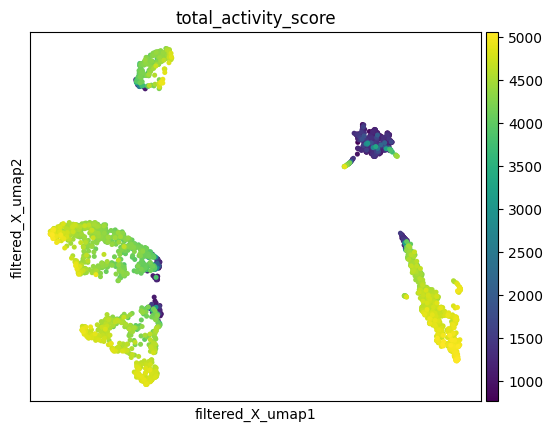

In [80]:
gene_matrix.obs['total_activity_score'] =  gene_matrix.X.sum(axis=1)

sc.pl.embedding(gene_matrix, basis="filtered_X_umap", use_raw=False, color=    ['total_activity_score'] )

# Save results

In [83]:
gene_matrix

AnnData object with n_obs × n_vars = 2286 × 42164
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'rna_pass_CR', 'atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS', '_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST', '_3set_identified_by_atac', 'DNA_debris', 'amulet_doublet_atac', 'leiden_RNA_scVI', 'total_fragments', 'FRIP_raw_peaks', 'FRIP_entropy_peaks', 'FRIP_tss_peaks', 'FRIP_frip_peaks', 'nucleosome_signal', 'tsse', 'leiden', 'leiden_scanpy', 'filtered_leiden', 'total_activity_score'
    var: 'n_cells'
    uns: 'log1p', 'leiden_colors', 'filtered_leiden_colors', 'leiden_RNA_scVI_colors'
    obsm: 'X_umap', 'filtered_X_umap'

In [85]:
cluster_average_df = pd.DataFrame(index=gene_matrix.var_names)

for c in gene_matrix.obs['filtered_leiden'].unique():
    a = gene_matrix[gene_matrix.obs['filtered_leiden'] == c, :].X.mean(axis=0)
    cluster_average_df[c] = np.asarray(a).flatten()


gene_activity_file = os.path.join(Union_cell_subdir, '_SNAPataC_analysis', 'filtered_leiden_cluster_average_gene_activity.csv')
cluster_average_df.to_csv(gene_activity_file)

cluster_average_df.head()

,9,0,2,3,5,4,11,1,8,6,7,10
DDX11L1,0.006192,-0.000265,-0.000090,0.005396,0.009194,0.004222,0.004665,0.008400,0.005341,0.003455,0.006073,0.011597
ENSG00000238009,0.001562,0.000259,-0.000336,0.002771,0.005044,0.000926,0.000593,0.004244,0.001162,0.000742,0.001480,0.003264
DDX11L17,0.013704,0.004166,0.009312,0.006436,0.008323,0.021762,0.016531,0.007969,0.011664,0.009858,0.011817,0.018674
WASH9P,0.004777,0.002714,0.001978,0.005787,0.009463,0.009853,0.007026,0.008218,0.004898,0.003735,0.006327,0.006227
ENSG00000228463,0.002078,0.000530,0.003067,0.015467,0.026384,0.002788,0.002331,0.022870,0.002649,0.002049,0.002864,0.002787


In [86]:
gene_matrix.write_h5ad(os.path.join(Union_cell_subdir, '_SNAPataC_analysis', 'gene_activity.h5ad'))

In [90]:
data.write_h5ad(os.path.join(Union_cell_subdir, '_SNAPataC_analysis', 'binnedGenome_all_unioncells.h5ad'))

In [91]:
data_filter.write_h5ad(os.path.join(Union_cell_subdir, '_SNAPataC_analysis', 'binnedGenome_unioncells_filtered.h5ad'))